In [18]:
from Tests import Tc
from thermopy.eos import PengRobinson, VanDerWaals
import numpy as np
import matplotlib.pyplot as plt

PengRobinson Pressure: 4156.968604987667, Van der Waals Pressure 4156.948702680499


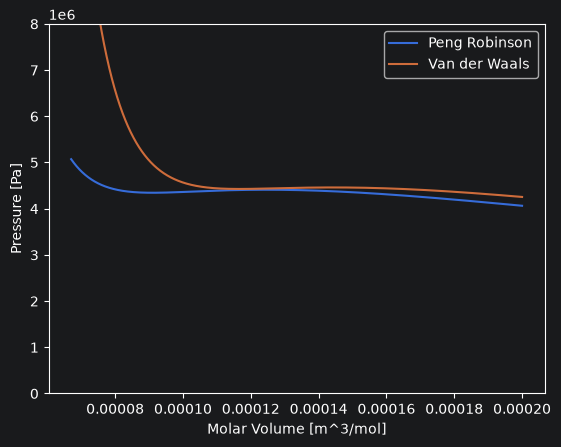

In [21]:
PR = PengRobinson("methane")
VdW = VanDerWaals("methane")


PRp = PR.P_from_TV(Temperature, Volume)
VdWp = VdW.P_from_TV(Temperature,Volume)

print(f"PengRobinson Pressure: {PRp}, Van der Waals Pressure {VdWp}")
Pc = 4599000 #[Pa]
Tc = 190.6 #[K]
Temp = 189 #[K]

b = PR.OMEGA * (8.314 * Tc) / Pc    #excluded molecule volume

#Determine pressures from volumes, volume lower bound is 1.5 * molecular volume
Vol_range = np.linspace(2.5*b, 2e-4, 5000)
Pressure_valsPR = [PR.P_from_TV(Temp, v) for v in Vol_range]
Pressure_valsVdW = [VdW.P_from_TV(Temp, v) for v in Vol_range]

plt.plot(Vol_range, Pressure_valsPR, label=f"Peng Robinson")
plt.plot(Vol_range, Pressure_valsVdW, label=f"Van der Waals")
plt.xlabel("Molar Volume [m^3/mol]")
plt.ylabel("Pressure [Pa]")
plt.legend()
plt.ylim(0, 0.8e7)
plt.show()

